In [1]:
# Instalar paquetes necesarios (para Colab)
!pip install neurodsp

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from neurodsp.spectral import compute_spectrum

# Escalas temporales (timescales) y rodillas espectrales (spectral knees)

Este notebook explora las escalas temporales (timescales), definidas como la tasa de decaimiento de una función exponencial. Esto está directamente relacionado, desde el punto de vista matemático, con la 'rodilla' espectral (knee) de la representación del espectro de potencia (power spectrum) de la señal en espacio log-log.

Para comenzar, se muestran el impulso unitario y los procesos puntuales de Poisson, que representan escalas temporales de duración extremadamente corta. En otras palabras, una sola señal impulsiva (distinta de cero) en una serie temporal puede pensarse como una función exponencial que decae instantáneamente, o infinitamente rápido.

Lo primero que hay que notar es que incluso para una señal sin ninguna oscilación, es decir, una señal formada completamente por ceros excepto en un punto no nulo, el espectro de potencia (power spectrum) tiene la misma potencia en todas las frecuencias. La lección aquí es que el hecho de que exista potencia en una frecuencia _no implica_ que exista una oscilación en esa frecuencia.

En la segunda mitad del notebook, se convolucionan varios kernels con decaimiento exponencial con el proceso puntual de Poisson para ilustrar la relación entre una señal con decaimiento exponencial en el dominio temporal y su representación en el espectro de potencia (power spectrum). Si el decaimiento del kernel está en el extremo más rápido, el producto se aproximará al proceso puntual original (ruido blanco). En el extremo más lento, el decaimiento del kernel se vuelve tan lento que el spectrum se aproxima a 1/f y una escala temporal (timescale) no puede medirse sin una señal lo suficientemente larga (por ejemplo, las escalas temporales de NMDA). Para capturar el rango más amplio posible de escalas temporales, la frecuencia de muestreo y la duración de la señal deberían aproximarse al infinito.

Para más información sobre cómo cuantificar escalas temporales (timescales), consulta [aquí](https://voyteklab.com/timescale-methods/).

## Impulso unitario discreto

El impulso unitario discreto (un caso específico del delta de Kronecker) se define como:

$$
\delta[n]=
\begin{cases}
  1, & \text{}\ n = 1 \\n  0, & \text{}\ n \neq 1
\end{cases}
$$

y representa una escala temporal (timescale) que se aproxima a cero (${\tau \to 0}$) o, de forma equivalente, al caso en que la frecuencia knee tiende a infinito ($f_k \to \inf$). En este límite, el espectro de potencia (power spectrum) se parece al del ruido blanco.


## Proceso puntual de Poisson

El impulso unitario puede extenderse a un proceso puntual de Poisson, donde el tiempo entre puntos (por ejemplo, 1s) sigue una distribución exponencial aleatoria:

$$
P[n]=
\begin{cases}
  1, & \text{}\ n \in \sum\limits_{}^{N} \lambda e^{\lambda x} \\n  0, & \text{otherwise}
\end{cases}
$$

donde el término de sumatoria corresponde al proceso de Poisson y $\lambda$ es su media y su desviación estándar. 

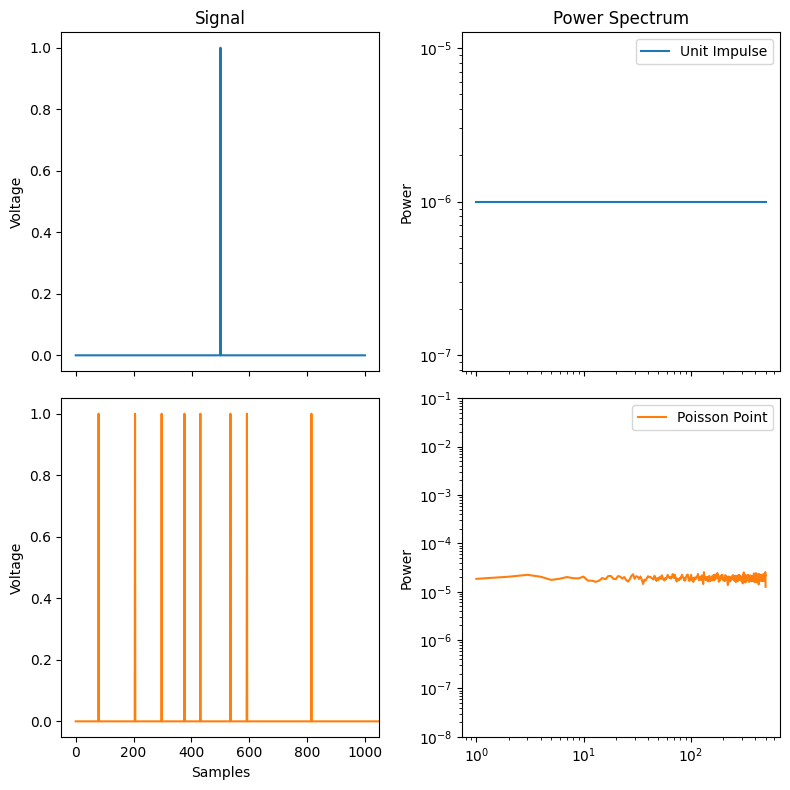

In [3]:
# frecuencia de muestreo
fs = 1000

# impulso unitario
sig_unit = np.zeros(fs) # simular un segundo de datos
sig_unit[int(fs / 2)] = 1 # en el punto medio
freqs_unit, powers_unit = compute_spectrum(sig_unit, fs, method='medfilt')

# punto de Poisson
np.random.seed(0)
seconds_to_sim = 100
sig_poisson = np.zeros(int(fs * seconds_to_sim))
inds = np.random.exponential(scale=100, size=len(sig_poisson)).cumsum().astype(int)
inds = inds[np.where(inds < len(sig_poisson))[0]]
sig_poisson[inds] = 1

freqs_poisson, powers_poisson = compute_spectrum(sig_poisson, fs, method='welch')

# graficar
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

axes[0, 0].plot(sig_unit)
axes[0, 1].loglog(freqs_unit[1:], powers_unit[1:], label='Unit Impulse')
axes[1, 0].plot(sig_poisson, color='C1')
axes[1, 1].loglog(freqs_poisson[1:], powers_poisson[1:], color='C1', label='Poisson Point')

# límites
axes[1, 0].set_xlim(-50, 1050)
axes[1, 1].set_ylim(1e-8, 1e-1)

# etiquetas
axes[0, 0].set_xticklabels([])
axes[0, 1].set_xticklabels([])
axes[1, 0].set_xlabel('Samples')
axes[0, 0].set_ylabel('Voltage')
axes[1, 0].set_ylabel('Voltage')
axes[0, 1].set_ylabel('Power')
axes[1, 1].set_ylabel('Power')
axes[0, 0].set_title('Signal')
axes[0, 1].set_title('Power Spectrum')

# leyenda
axes[0, 1].legend()
axes[1, 1].legend()

plt.tight_layout()

## Escalas temporales (timescales)

El proceso puntual de Poisson puede convolucionarse con un kernel de decaimiento exponencial para producir escalas temporales (timescales), cuantificadas como frecuencias knee (líneas punteadas). Para demostrarlo, se eligen tres kernels con distintas tasas de decaimiento:

1. Límite inferior (rápido): el decaimiento del kernel es aproximadamente instantáneo, produciendo un spectrum parecido al ruido blanco o gaussiano (morado). Se necesitan frecuencias de muestreo altas para escalas temporales que se acerquen a este límite inferior.
2. Entre los límites inferior y superior se encuentran escalas temporales con knees espectrales más claramente definidos (rojo).
3. Límite superior (lento): el decaimiento del kernel se vuelve aproximadamente tan largo como el mínimo de la resolución en frecuencia, acercándose a una dinámica 1/f (verde). Se necesitan señales más largas a medida que las escalas temporales se aproximan a este límite. 

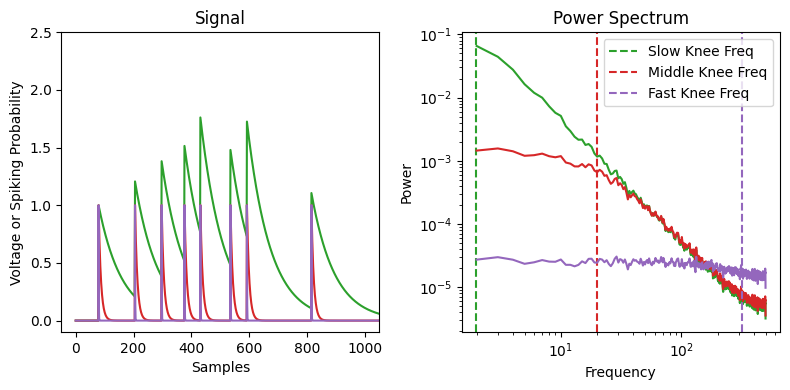

In [4]:
# convolucionar el proceso puntual de Poisson
#   con un kernel de decaimiento exponencial
taus = np.array([t/fs for t in [80, 8, .5]])
knees = 1/(2*np.pi*taus)

sig_taus = np.zeros((len(taus), len(sig_poisson)))

for i, tau in enumerate(taus):
    kernel = np.exp(-np.arange(1000)/(tau*fs))
    sig_taus[i] = np.convolve(sig_poisson, kernel)[:len(sig_poisson)]

# graficar
fig, axes = plt.subplots(ncols=2, figsize=(8, 4))

colors = ['C2', 'C3', 'C4']
labels = ['Slow', 'Middle', 'Fast']
for s, c in zip(sig_taus, colors):
    axes[0].plot(s, color=c)

for s, t, c, l in zip(sig_taus, taus, colors, labels):
    freqs_tau, powers_tau = compute_spectrum(s, fs, f_range=(1, 1200))
    axes[1].loglog(freqs_tau[1:], powers_tau[1:], color=c)
    axes[1].axvline(1/(t*2*np.pi), color=c, ls='--', label=l+' Knee Freq')
    
# títulos
axes[0].set_title('Signal')
axes[1].set_title('Power Spectrum')

# etiquetas
axes[0].set_ylabel('Voltage or Spiking Probability')
axes[0].set_xlabel('Samples')
axes[1].set_ylabel('Power')
axes[1].set_xlabel('Frequency')

axes[0].set_ylim(-.1, 2.5)
axes[0].set_xlim(-50, 1050)

axes[1].legend()

plt.tight_layout()

Observa que la frecuencia knee más baja es lo suficientemente baja como para que tal vez no pueda detectarse fácilmente con la duración de una época típica de i/EEG alineada a eventos de una tarea cognitiva. Esto demuestra la importancia de comprender la relación entre la longitud de tu señal y las escalas temporales (timescales) de interés. Además, en datos neurales empíricos probablemente cualquier registro electrofisiológico esté captando actividad de múltiples fuentes y, por tanto, contenga múltiples escalas temporales. Esto hace que la interpretación de las escalas temporales medidas empíricamente pueda ser más compleja que la de estas corrientes simuladas. 

En el conjunto de notebooks de 'specparam' discutiremos cómo el algoritmo de ajuste del modelo tiene en cuenta la presencia de un knee en los espectros de potencia (power spectra).